In [129]:
from sklearn.datasets import make_classification
X,y=make_classification(n_features=2,n_samples=100,n_redundant=0,n_classes=2,n_informative=1,n_clusters_per_class=1,
                        random_state=41,hypercube=False,
                        class_sep=20)
import numpy as np
import pandas as pd

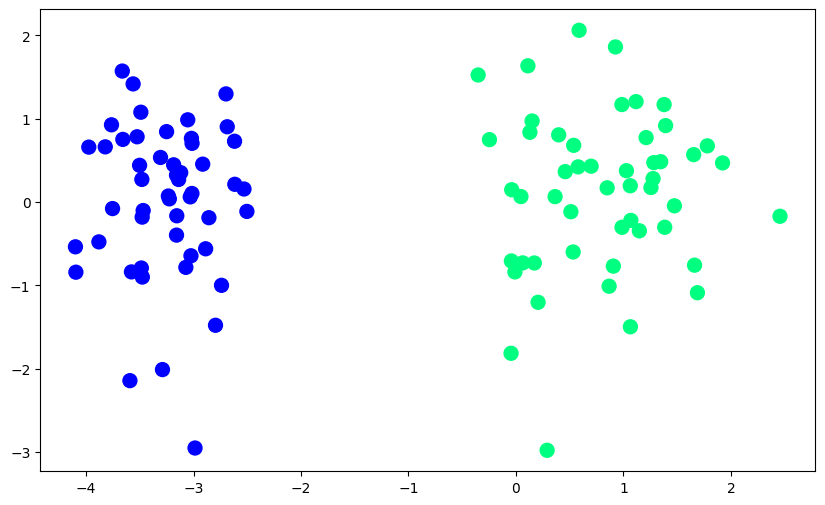

In [130]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1:],c=y,cmap='winter',s=100)
plt.show()

In [131]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(penalty=None,solver='sag')
lr.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [132]:
print(lr.coef_)
print(lr.intercept_)

[[4.83803451 0.22188402]]
[5.80484153]


In [133]:
m=-(lr.coef_[0][0]/lr.coef_[0][1])
b=-(lr.intercept_/lr.coef_[0][1])

In [134]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+b

In [144]:
def gd(X,y):
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.5
  for i in range(5000):
    y_hat=sigmoid(np.dot(X,weights))
    weights=weights+lr*(np.dot((y-y_hat),X)/X.shape[0])
  return weights[1:],weights[0]



In [136]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [145]:
coef_,intercept_=gd(X,y)
print(coef_)
print(intercept_)

[4.83926872 0.21182255]
5.83338864905325


In [141]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [139]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

(-3.0, 2.0)

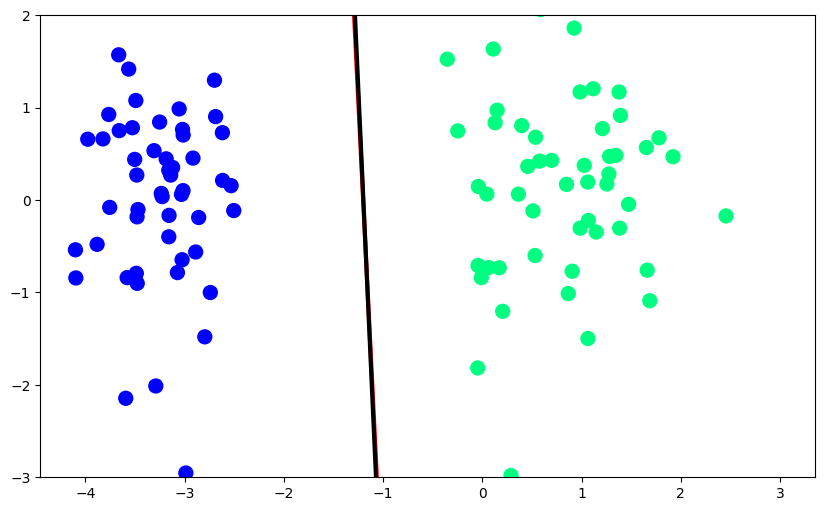

In [140]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
